# Clinical Outcome Prediction from Noisy Medical Records

**CS30721 Data Sciences Project — Stage 1 & 2**

In this project we work with a real dataset of diabetic patients from 130 US hospitals (1999–2008).
Our goal is to clean the data, explore it, and build a machine learning model that predicts whether a patient will be readmitted to the hospital.

---

**Table of Contents:**
1. Imports & Load Data
2. Dataset Understanding
3. Initial Overview
4. Exploratory Data Analysis (EDA)
5. Data Cleaning
6. Target Variable Setup
7. Encoding Categorical Features
8. Feature Ranking
9. Feature Scaling
10. Dimensionality Reduction (PCA)
11. Label Noise (Adversarial Condition)
12. Stage 2 — Machine Learning Models
13. Final Summary

---
## 1. Imports & Load Data

In [11]:
# Import all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

print('Libraries imported successfully!')

Libraries imported successfully!


In [12]:
# Load the dataset
# In Google Colab, upload the file first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('diabetic_data.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Dataset loaded: 101,766 rows, 50 columns


---
## 2. Dataset Understanding

Before we touch any data, we need to understand what each feature means.

The dataset has **50 features** divided into groups:

| Group | Features | Count |
|-------|----------|-------|
| Identifiers | encounter_id, patient_nbr | 2 |
| Demographics | race, gender, age, weight | 4 |
| Hospital info | admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital, payer_code, medical_specialty | 6 |
| Clinical numbers | num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses | 7 |
| Diagnosis codes | diag_1, diag_2, diag_3 | 3 |
| Lab results | max_glu_serum, A1Cresult | 2 |
| Medications | metformin, insulin, glipizide... (23 columns) | 23 |
| **Target** | **readmitted** | 1 |

**Target variable `readmitted`:**
- `NO` → patient was NOT readmitted
- `<30` → readmitted within 30 days (serious!)
- `>30` → readmitted after 30 days

---
## 3. Initial Overview

In [13]:
# Basic info about the dataset
print('Shape:', df.shape)
print()
print('Column types:')
print(df.dtypes.value_counts())
print()
print('First 5 rows:')
df.head()

Shape: (101766, 50)

Column types:
object    37
int64     13
Name: count, dtype: int64

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [14]:
# Check for missing values
# In this dataset, missing values are written as '?' not NaN
# So we replace '?' with NaN first
df_check = df.replace('?', np.nan)

missing = df_check.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
result = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
result = result[result['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(result)

Columns with missing values:
                   Missing Count  Missing %
weight                     98569       96.9
max_glu_serum              96420       94.7
A1Cresult                  84748       83.3
medical_specialty          49949       49.1
payer_code                 40256       39.6
race                        2273        2.2
diag_3                      1423        1.4
diag_2                       358        0.4
diag_1                        21        0.0


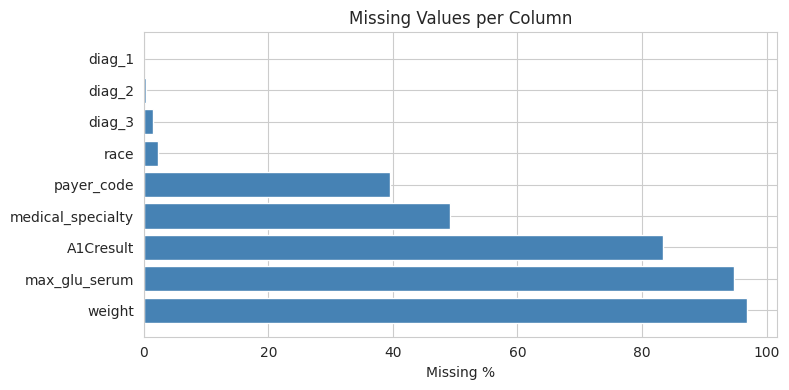


Decision:
- weight is 97% missing → we will DROP it (cannot impute)
- max_glu_serum and A1Cresult are >80% missing → keep as category (missing = test not done)
- race, payer_code, medical_specialty → fill with Unknown


In [15]:
# Visualize missing values
plt.figure(figsize=(8, 4))
plt.barh(result.index, result['Missing %'], color='steelblue')
plt.xlabel('Missing %')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

print('\nDecision:')
print('- weight is 97% missing → we will DROP it (cannot impute)')
print('- max_glu_serum and A1Cresult are >80% missing → keep as category (missing = test not done)')
print('- race, payer_code, medical_specialty → fill with Unknown')

---
## 4. Exploratory Data Analysis (EDA)

EDA means we look at the data carefully before cleaning or modeling.
Every decision we make later must be based on what we see here — not random choices.

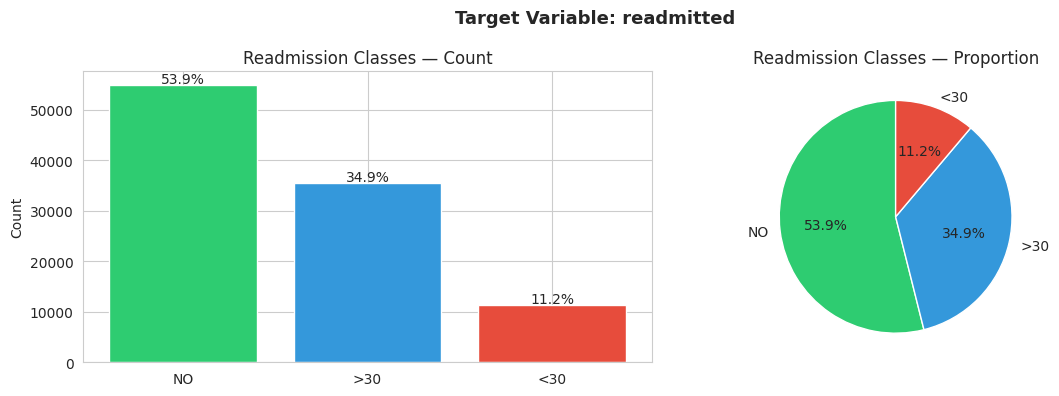

Insight: The data is IMBALANCED.
  NO (not readmitted):  53.9%
  >30 (after 30 days):  34.9%
  <30 (within 30 days): 11.2%

Decision: We will combine >30 and <30 into one class (Readmitted = 1).
This makes it a binary classification: 0 = No, 1 = Readmitted


In [16]:
# --- 4.1 Target Variable Distribution ---
# The most important thing to analyze first is our target variable

target_counts = df['readmitted'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = {'NO': '#2ecc71', '>30': '#3498db', '<30': '#e74c3c'}
axes[0].bar(target_counts.index,
            target_counts.values,
            color=[colors[c] for c in target_counts.index])
axes[0].set_title('Readmission Classes — Count')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 400, f'{p}%', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values,
            labels=target_counts.index,
            colors=[colors[c] for c in target_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Readmission Classes — Proportion')

plt.suptitle('Target Variable: readmitted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: The data is IMBALANCED.')
print(f'  NO (not readmitted):  {target_pct["NO"]}%')
print(f'  >30 (after 30 days):  {target_pct[">30"]}%')
print(f'  <30 (within 30 days): {target_pct["<30"]}%')
print()
print('Decision: We will combine >30 and <30 into one class (Readmitted = 1).')
print('This makes it a binary classification: 0 = No, 1 = Readmitted')

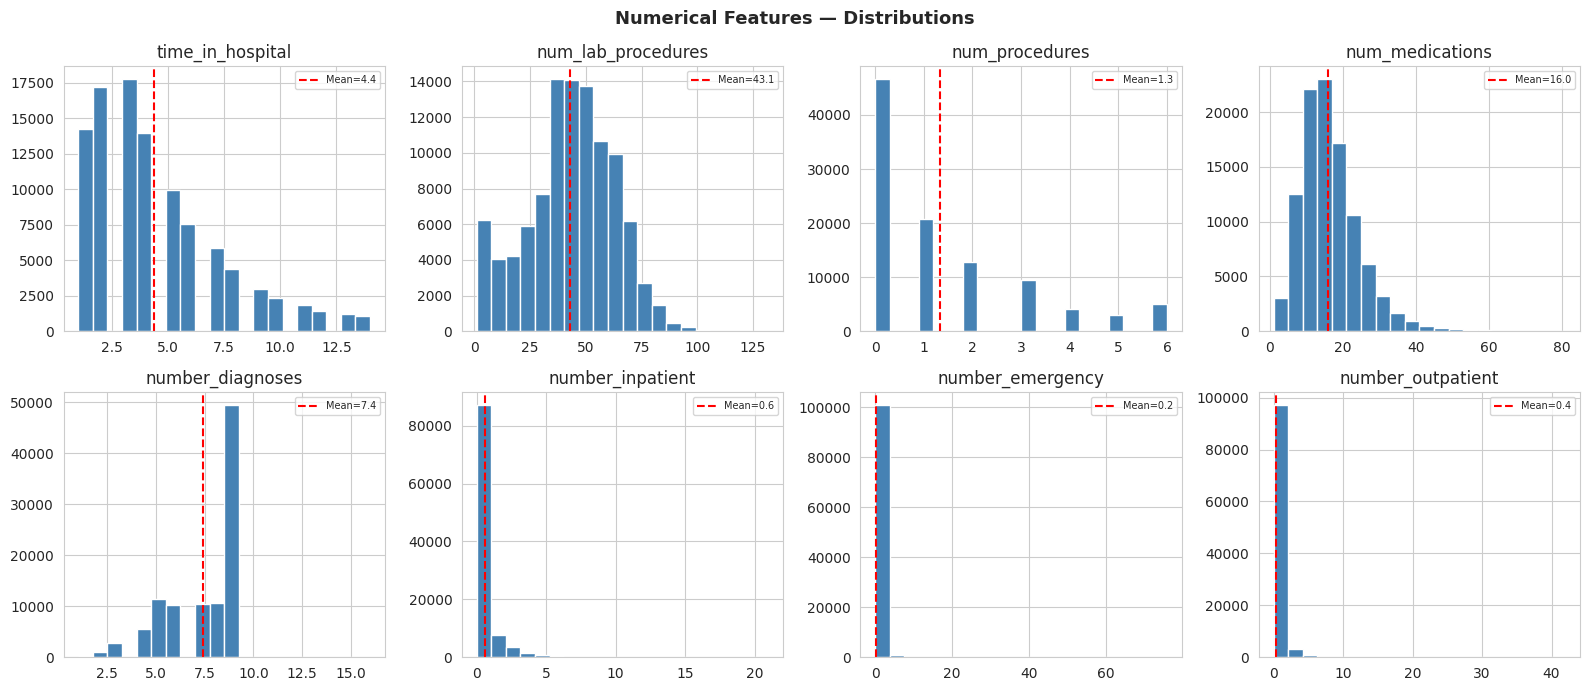

In [17]:
# --- 4.2 Numerical Features: Histograms ---
# We look at how numerical features are distributed

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_inpatient',
            'number_emergency', 'number_outpatient']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Numerical Features — Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

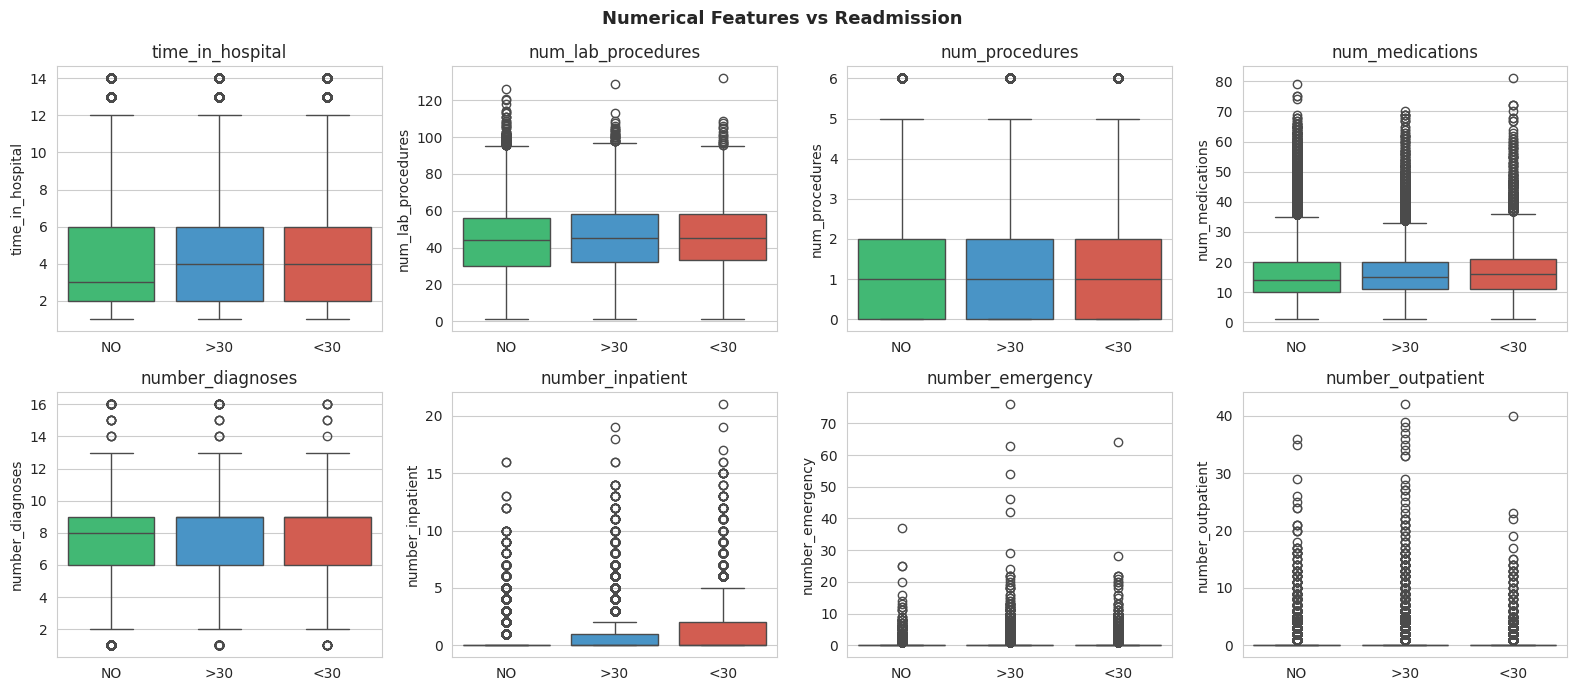

Insight:
  - number_inpatient: clearly higher for readmitted patients → strong predictor
  - time_in_hospital: slightly higher for readmitted → useful
  - number_outpatient: almost same across classes → weaker predictor


In [18]:
# --- 4.3 Numerical Features vs Target: Boxplots ---
# This shows if a feature is different across readmission classes
# Features with different boxes = more useful for prediction

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

order = ['NO', '>30', '<30']
palette = {'NO': '#2ecc71', '>30': '#3498db', '<30': '#e74c3c'}

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='readmitted', y=col,
                order=order, palette=palette, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Numerical Features vs Readmission', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight:')
print('  - number_inpatient: clearly higher for readmitted patients → strong predictor')
print('  - time_in_hospital: slightly higher for readmitted → useful')
print('  - number_outpatient: almost same across classes → weaker predictor')

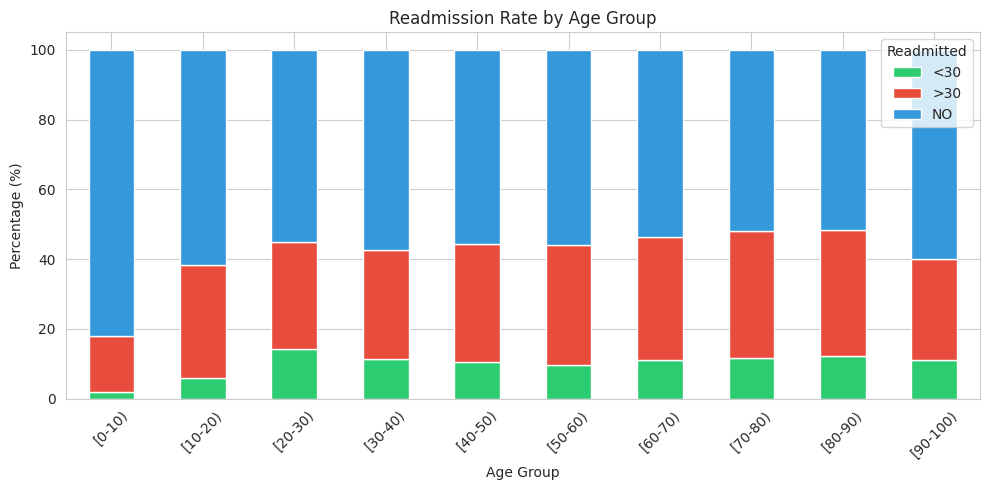

Insight: Older patients (60-90) have higher readmission rates.
This justifies encoding age as ORDINAL (0-10), not one-hot encoding.


In [19]:
# --- 4.4 Age vs Readmission ---
# We want to know: do older patients get readmitted more?

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
age_readmit = age_readmit.reindex(age_order)

age_readmit.plot(kind='bar', stacked=True,
                 color=['#2ecc71', '#e74c3c', '#3498db'],
                 figsize=(10, 5), edgecolor='white')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

print('Insight: Older patients (60-90) have higher readmission rates.')
print('This justifies encoding age as ORDINAL (0-10), not one-hot encoding.')

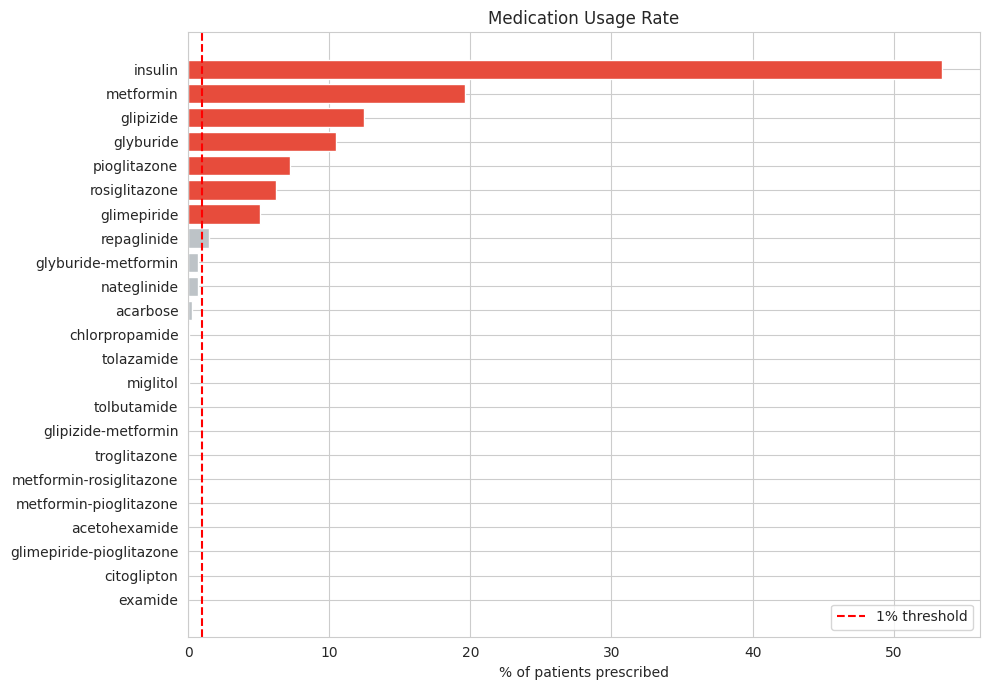

Medications with < 1% usage (will be removed): ['examide', 'citoglipton', 'glimepiride-pioglitazone', 'acetohexamide', 'metformin-pioglitazone', 'metformin-rosiglitazone', 'troglitazone', 'glipizide-metformin', 'tolbutamide', 'miglitol', 'tolazamide', 'chlorpropamide', 'acarbose', 'nateglinide', 'glyburide-metformin']


In [20]:
# --- 4.5 Medication Columns: How many are actually used? ---
# There are 23 medication columns. Most patients are on 'No' (not prescribed).
# Columns where almost everyone has 'No' = useless for prediction.

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Calculate how many patients actually use each medication (not 'No')
usage = {col: (df[col] != 'No').sum() / len(df) * 100 for col in med_cols}
usage_series = pd.Series(usage).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if v > 5 else '#bdc3c7' for v in usage_series.values]
plt.barh(usage_series.index, usage_series.values, color=colors_bar)
plt.axvline(x=1, color='red', linestyle='--', label='1% threshold')
plt.xlabel('% of patients prescribed')
plt.title('Medication Usage Rate')
plt.legend()
plt.tight_layout()
plt.show()

low_use = usage_series[usage_series < 1].index.tolist()
print(f'Medications with < 1% usage (will be removed): {low_use}')

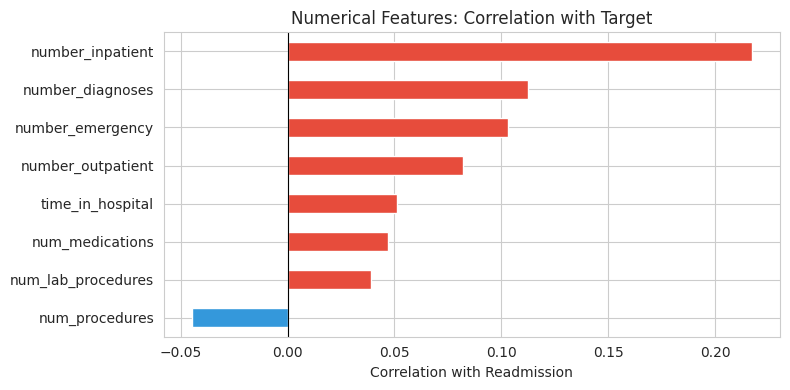

Insight:
Positive = higher value → more likely to be readmitted
number_inpatient has the strongest positive correlation


In [21]:
# --- 4.6 Correlation between numerical features and target ---
# We create a temporary binary target to measure correlations

df_temp = df.copy()
df_temp['target'] = (df_temp['readmitted'] != 'NO').astype(int)

corr_values = df_temp[num_cols + ['target']].corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8, 4))
corr_values.plot(kind='barh',
                 color=['#e74c3c' if v > 0 else '#3498db' for v in corr_values])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Readmission')
plt.title('Numerical Features: Correlation with Target')
plt.tight_layout()
plt.show()

print('Insight:')
print('Positive = higher value → more likely to be readmitted')
print('number_inpatient has the strongest positive correlation')

---
## 5. Data Cleaning

Now we clean the data based on what we found in EDA.
Every step has a clear reason — nothing is random.

In [22]:
# Start with a clean copy
df_clean = df.copy()

# Step 1: Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)
print('Step 1 done: replaced ? with NaN')

Step 1 done: replaced ? with NaN


In [23]:
# Step 2: Handle duplicate patients
# The same patient can appear multiple times (multiple hospital visits)
# We keep only the FIRST visit to avoid data leakage
print(f'Total records: {len(df_clean):,}')
print(f'Unique patients: {df_clean["patient_nbr"].nunique():,}')

df_clean = df_clean.drop_duplicates(subset='patient_nbr', keep='first')
print(f'After keeping first visit per patient: {len(df_clean):,}')

Total records: 101,766
Unique patients: 71,518
After keeping first visit per patient: 71,518


In [24]:
# Step 3: Drop identifier columns (no predictive value)
df_clean.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)
print('Dropped identifier columns: encounter_id, patient_nbr')

Dropped identifier columns: encounter_id, patient_nbr


In [25]:
# Step 4: Drop 'weight' column
# Reason: 97% missing. Impossible to impute reliably.
df_clean.drop('weight', axis=1, inplace=True)
print('Dropped: weight (97% missing)')

Dropped: weight (97% missing)


In [26]:
# Step 5: Handle lab result columns
# Instead of dropping them (clinically important!),
# we fill NaN with 'None' — meaning the test was never done.
# 'Test not done' is itself a useful medical signal.
for col in ['max_glu_serum', 'A1Cresult']:
    df_clean[col] = df_clean[col].fillna('None')
print('max_glu_serum and A1Cresult: NaN → None')

max_glu_serum and A1Cresult: NaN → None


In [27]:
# Step 6: Fill missing values in other categorical columns
for col in ['race', 'payer_code', 'medical_specialty']:
    df_clean[col] = df_clean[col].fillna('Unknown')
print('race, payer_code, medical_specialty: NaN → Unknown')

race, payer_code, medical_specialty: NaN → Unknown


In [28]:
# Step 7: Remove zero-variance features
# These are columns where ALL values are the same → useless for prediction
zero_var = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f'Zero-variance columns found: {zero_var}')
if zero_var:
    df_clean.drop(zero_var, axis=1, inplace=True)
    print(f'Dropped {len(zero_var)} zero-variance columns')

Zero-variance columns found: ['examide', 'citoglipton', 'glimepiride-pioglitazone']
Dropped 3 zero-variance columns


In [29]:
# Step 8: Remove near-zero-variance medication columns (<1% usage)
low_use_meds = [col for col in med_cols
                if col in df_clean.columns
                and (df_clean[col] != 'No').sum() / len(df_clean) < 0.01]
df_clean.drop(low_use_meds, axis=1, inplace=True)
print(f'Dropped {len(low_use_meds)} near-zero medication columns: {low_use_meds}')

Dropped 12 near-zero medication columns: ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [30]:
# Step 9: Remove rows with invalid gender
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']
print('Removed rows with invalid gender')

# Step 10: Remove patients who died (discharge_disposition = 11,13,14,19,20,21)
# These patients cannot be readmitted — including them would confuse the model
dead_codes = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(dead_codes)]
print('Removed patients who died or went to hospice')

print(f'\nFinal cleaned shape: {df_clean.shape}')

Removed rows with invalid gender
Removed patients who died or went to hospice

Final cleaned shape: (69970, 32)


---
## 6. Target Variable Setup

In [31]:
# Create binary target
# Based on EDA: the data is ~54% NO vs ~46% Readmitted
# Binary classification is the right approach for this problem

df_clean['readmitted_binary'] = (df_clean['readmitted'] != 'NO').astype(int)

print('Target distribution:')
print(df_clean['readmitted_binary'].value_counts())
print()
print('0 = Not Readmitted')
print('1 = Readmitted (either <30 or >30 days)')

# Save target and drop original column
y = df_clean['readmitted_binary'].copy()
df_clean.drop(['readmitted', 'readmitted_binary'], axis=1, inplace=True)

Target distribution:
readmitted_binary
0    41471
1    28499
Name: count, dtype: int64

0 = Not Readmitted
1 = Readmitted (either <30 or >30 days)


---
## 7. Encoding Categorical Features

Machine learning models only understand numbers, not text.
We need to convert all text columns to numbers.

In [32]:
# Age → Ordinal encoding (1 to 10)
# We use ordinal because age has a natural order: older = higher number
age_map = {
    '[0-10)': 1, '[10-20)': 2, '[20-30)': 3, '[30-40)': 4, '[40-50)': 5,
    '[50-60)': 6, '[60-70)': 7, '[70-80)': 8, '[80-90)': 9, '[90-100)': 10
}
df_clean['age'] = df_clean['age'].map(age_map)
print('Age encoded as 1-10')

Age encoded as 1-10


In [33]:
# Medication columns → Ordinal encoding (0 to 3)
# No=0, Steady=1, Down=2, Up=3
# This captures the intensity of medication usage
med_encode = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

current_meds = [col for col in med_cols
                if col in df_clean.columns
                and df_clean[col].dtype == object]

for col in current_meds:
    df_clean[col] = df_clean[col].map(med_encode).fillna(0).astype(int)

print(f'Encoded {len(current_meds)} medication columns: No=0, Steady=1, Down=2, Up=3')

Encoded 8 medication columns: No=0, Steady=1, Down=2, Up=3


In [34]:
# Binary columns
if 'gender' in df_clean.columns:
    df_clean['gender'] = (df_clean['gender'] == 'Male').astype(int)
if 'change' in df_clean.columns:
    df_clean['change'] = (df_clean['change'] == 'Ch').astype(int)
if 'diabetesMed' in df_clean.columns:
    df_clean['diabetesMed'] = (df_clean['diabetesMed'] == 'Yes').astype(int)
print('Binary columns encoded: gender, change, diabetesMed')

Binary columns encoded: gender, change, diabetesMed


In [35]:
# Reduce cardinality of high-cardinality columns before OHE
# medical_specialty has too many values — keep only top 5
if 'medical_specialty' in df_clean.columns:
    top5 = df_clean['medical_specialty'].value_counts().nlargest(5).index
    df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(
        lambda x: x if x in top5 else 'Other'
    )

# diag_1/2/3: Group ICD codes into disease categories
def simplify_diag(code):
    if pd.isna(code): return 'Unknown'
    code = str(code)
    if code.startswith('V') or code.startswith('E'): return 'Other'
    try:
        n = float(code.split('.')[0])
    except:
        return 'Unknown'
    if 390 <= n <= 459: return 'Circulatory'
    if 460 <= n <= 519: return 'Respiratory'
    if 520 <= n <= 579: return 'Digestive'
    if n == 250: return 'Diabetes'
    if 800 <= n <= 999: return 'Injury'
    if 140 <= n <= 239: return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(simplify_diag)
print('Diagnosis codes grouped into disease categories')

Diagnosis codes grouped into disease categories


In [37]:
# One-Hot Encoding for remaining text columns
remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Columns to one-hot encode: {remaining_cat}')

df_encoded = pd.get_dummies(df_clean, columns=remaining_cat, drop_first=True)
print(f'\nAfter encoding: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns')

Columns to one-hot encode: ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']

After encoding: 69,970 rows × 77 columns


---
## 8. Feature Ranking

We use Random Forest to find out which features are most useful.
This helps us remove noisy/unimportant features before building the model.

**Important:** We rank ALL features, not just the numerical ones.

In [38]:
X_all = df_encoded.copy()
y_all = y.reindex(X_all.index)

# Train a simple Random Forest to get feature importance
print('Training Random Forest for feature ranking...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,           # Keep it simple
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_all, y_all)

# Get and sort feature importances
importance_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 20 features:')
print(importance_df.head(20).to_string())

Training Random Forest for feature ranking...
Top 20 features:
                     Feature  Importance
0           number_inpatient    0.200909
1           number_diagnoses    0.121729
2          number_outpatient    0.059915
3           number_emergency    0.059259
4                        age    0.056055
5        admission_source_id    0.052786
6            num_medications    0.046028
7         num_lab_procedures    0.039988
8           time_in_hospital    0.035180
9          admission_type_id    0.029814
10  discharge_disposition_id    0.028970
11               diabetesMed    0.024362
12        payer_code_Unknown    0.020051
13            num_procedures    0.017811
14                   insulin    0.014415
15   medical_specialty_Other    0.009983
16            race_Caucasian    0.008468
17             payer_code_MC    0.008112
18           diag_1_Diabetes    0.007501
19                    change    0.007269


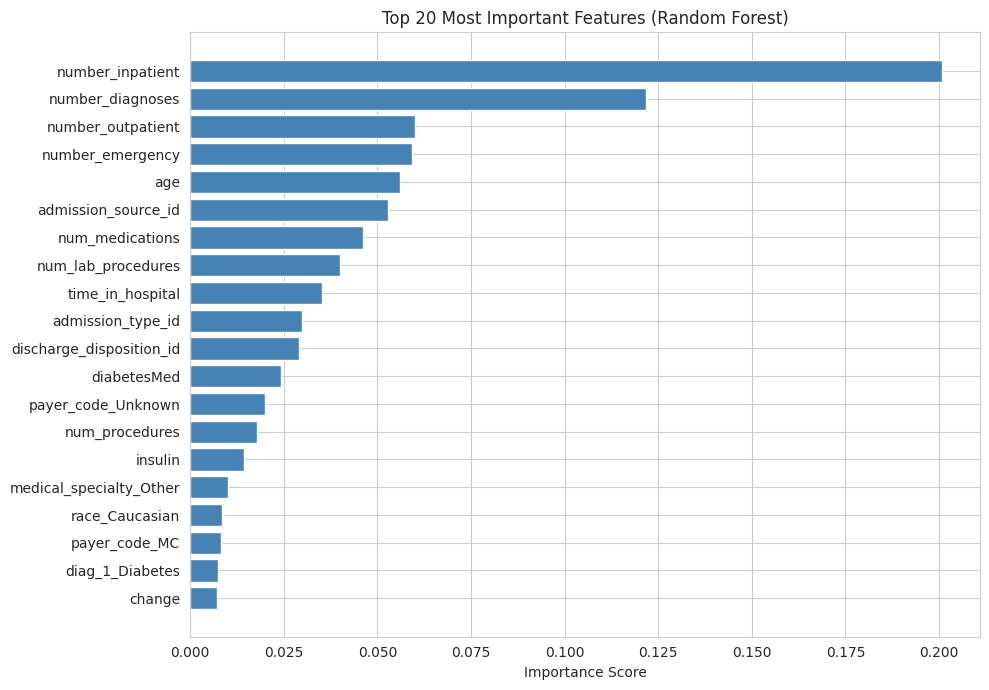


Selected top 21 features (cover 85% of importance)


In [39]:
# Plot top 20 features
plt.figure(figsize=(10, 7))
top20 = importance_df.head(20)
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

# Select features that cover 85% of total importance
cumsum = importance_df['Importance'].cumsum()
n_features = (cumsum < 0.85).sum() + 1
selected_features = importance_df.head(n_features)['Feature'].tolist()
print(f'\nSelected top {n_features} features (cover 85% of importance)')

X_selected = X_all[selected_features]

---
## 9. Feature Scaling

StandardScaler transforms all features to have mean=0 and std=1.
This is required before PCA because PCA is sensitive to the scale of features.

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print(f'Scaled {X_selected.shape[1]} features')
print(f'Mean (should be ≈0): {X_scaled.mean():.4f}')
print(f'Std  (should be ≈1): {X_scaled.std():.4f}')

Scaled 21 features
Mean (should be ≈0): -0.0000
Std  (should be ≈1): 1.0000


---
## 10. Dimensionality Reduction (PCA)

PCA reduces the number of features while keeping most of the information.
We apply it AFTER feature ranking — not before (common mistake).

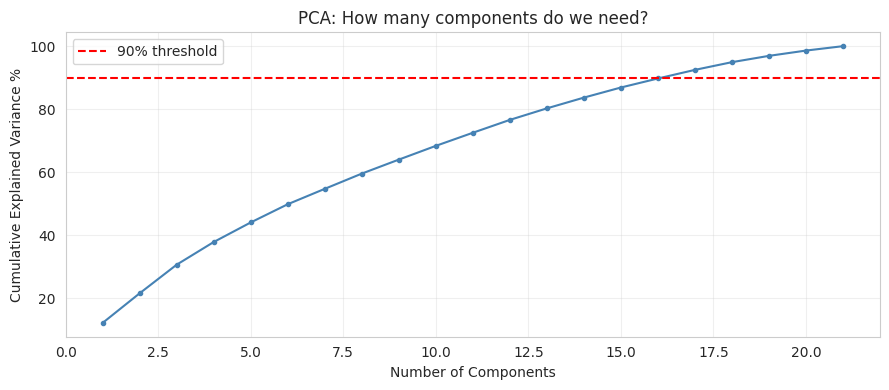

We need 17 components to explain 90% of the variance


In [41]:
# Run PCA and plot explained variance
pca_check = PCA(random_state=42)
pca_check.fit(X_scaled)

cumulative_var = np.cumsum(pca_check.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', markersize=3, color='steelblue')
plt.axhline(y=90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance %')
plt.title('PCA: How many components do we need?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find how many components explain 90% of variance
n_comp = int(np.argmax(cumulative_var >= 90)) + 1
print(f'We need {n_comp} components to explain 90% of the variance')

In [42]:
# Apply PCA with the chosen number of components
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA result: {X_scaled.shape[1]} features → {n_comp} components')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA result: 21 features → 17 components
Variance retained: 92.5%


---
## 11. Adversarial Condition — Label Noise

In real medical data, records contain errors (wrong diagnosis, wrong readmission status).
We simulate this by randomly flipping 10% of labels.

In [43]:
np.random.seed(42)
n_flip = int(0.10 * len(y_all))
flip_idx = np.random.choice(len(y_all), n_flip, replace=False)

y_noisy = y_all.copy()
y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]

print(f'Flipped {n_flip:,} labels (10%)')
print(f'Original: {y_all.value_counts().to_dict()}')
print(f'Noisy:    {y_noisy.value_counts().to_dict()}')
print()
print('y_all   = clean labels (use for normal training)')
print('y_noisy = noisy labels (use to test model robustness)')

Flipped 6,997 labels (10%)
Original: {0: 41471, 1: 28499}
Noisy:    {0: 40144, 1: 29826}

y_all   = clean labels (use for normal training)
y_noisy = noisy labels (use to test model robustness)


---
## 12. Stage 2 — Machine Learning Models

Now we train and compare different models to find the best one for predicting readmission.

We will try:
1. **Logistic Regression** — simple and fast, good baseline
2. **Decision Tree** — easy to understand and explain
3. **Random Forest** — usually gives best accuracy

Then we pick the best one based on accuracy and AUC score.

In [44]:
# Split the data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'Class distribution in training:')
print(pd.Series(y_train).value_counts())

Training set: 55,976 samples
Test set:     13,994 samples
Class distribution in training:
readmitted_binary
0    33177
1    22799
Name: count, dtype: int64


In [45]:
# --- Model 1: Logistic Regression ---
# A simple linear model. Good as a baseline.

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_test, lr_prob):.3f}')
print()
print(classification_report(y_test, lr_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Logistic Regression ===
Accuracy: 0.593
AUC Score: 0.626

                precision    recall  f1-score   support

Not Readmitted       0.67      0.63      0.65      8294
    Readmitted       0.50      0.54      0.52      5700

      accuracy                           0.59     13994
     macro avg       0.58      0.58      0.58     13994
  weighted avg       0.60      0.59      0.59     13994



In [46]:
# --- Model 2: Decision Tree ---
# A model that makes decisions based on simple if/else rules.
# Easy to understand and visualize.

dt_model = DecisionTreeClassifier(
    max_depth=6,            # Keep tree simple (avoid overfitting)
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print('=== Decision Tree ===')
print(f'Accuracy: {accuracy_score(y_test, dt_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_test, dt_prob):.3f}')
print()
print(classification_report(y_test, dt_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Decision Tree ===
Accuracy: 0.569
AUC Score: 0.602

                precision    recall  f1-score   support

Not Readmitted       0.66      0.55      0.60      8294
    Readmitted       0.48      0.59      0.53      5700

      accuracy                           0.57     13994
     macro avg       0.57      0.57      0.57     13994
  weighted avg       0.59      0.57      0.57     13994



In [47]:
# --- Model 3: Random Forest ---
# An ensemble of many decision trees. Usually the most accurate.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_test, rf_prob):.3f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Random Forest ===
Accuracy: 0.599
AUC Score: 0.635

                precision    recall  f1-score   support

Not Readmitted       0.68      0.62      0.65      8294
    Readmitted       0.51      0.57      0.54      5700

      accuracy                           0.60     13994
     macro avg       0.59      0.59      0.59     13994
  weighted avg       0.61      0.60      0.60     13994



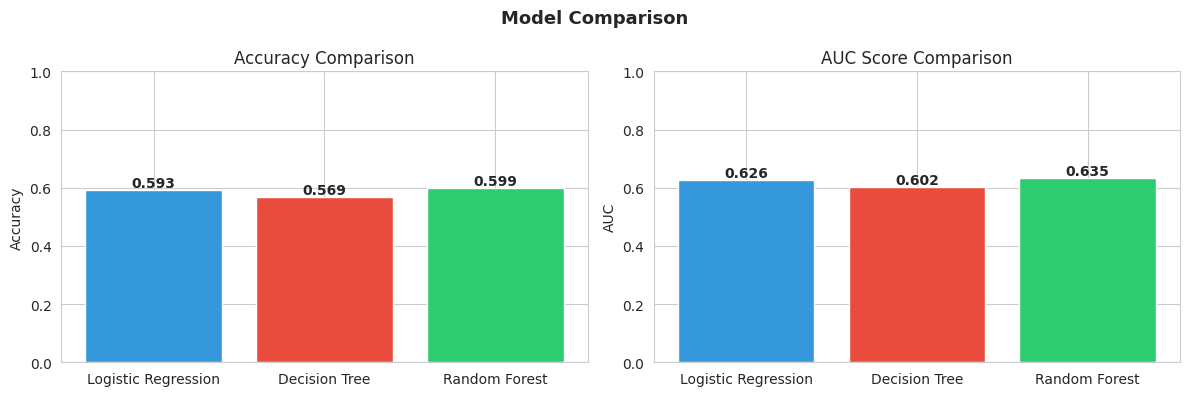


✅ Best model: Random Forest
   AUC: 0.635


In [48]:
# --- Compare all models visually ---
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]
aucs = [
    roc_auc_score(y_test, lr_prob),
    roc_auc_score(y_test, dt_prob),
    roc_auc_score(y_test, rf_prob)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
axes[0].bar(models, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# AUC comparison
axes[1].bar(models, aucs, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('AUC Score Comparison')
axes[1].set_ylabel('AUC')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_idx = np.argmax(aucs)
print(f'\n✅ Best model: {models[best_idx]}')
print(f'   AUC: {aucs[best_idx]:.3f}')

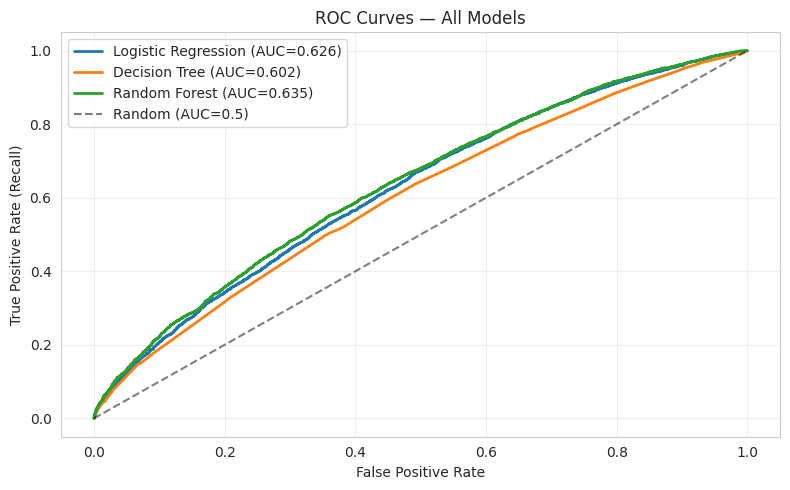

The closer the curve is to the top-left corner, the better the model.
AUC=1.0 is perfect, AUC=0.5 is random guessing.


In [49]:
# --- ROC Curves for all models ---
plt.figure(figsize=(8, 5))

for name, prob in zip(models, [lr_prob, dt_prob, rf_prob]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('The closer the curve is to the top-left corner, the better the model.')
print('AUC=1.0 is perfect, AUC=0.5 is random guessing.')

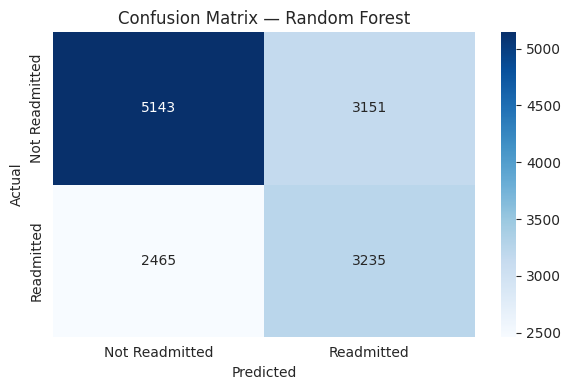

True Negatives  (correct: not readmitted): 5,143
True Positives  (correct: readmitted):     3,235
False Positives (wrong: said readmitted):  3,151
False Negatives (missed: readmitted):      2,465


In [50]:
# --- Confusion Matrix for the best model ---
best_pred = [lr_pred, dt_pred, rf_pred][best_idx]
best_name = models[best_idx]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct: not readmitted): {tn:,}')
print(f'True Positives  (correct: readmitted):     {tp:,}')
print(f'False Positives (wrong: said readmitted):  {fp:,}')
print(f'False Negatives (missed: readmitted):      {fn:,}')

In [51]:
# --- Cross Validation for the best model ---
# Cross-validation gives a more reliable estimate of model performance
# It tests the model on 5 different splits of the data

best_model = [lr_model, dt_model, rf_model][best_idx]

cv_scores = cross_val_score(best_model, X_pca, y_all,
                             cv=5, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold Cross-Validation AUC ({best_name}):')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1}: {s:.3f}')
print(f'  Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()
if cv_scores.std() < 0.05:
    print('✅ Low variance across folds = model is stable (no overfitting)')
else:
    print('⚠️ High variance = model may be overfitting, consider simplifying')

5-Fold Cross-Validation AUC (Random Forest):
  Fold 1: 0.601
  Fold 2: 0.659
  Fold 3: 0.588
  Fold 4: 0.603
  Fold 5: 0.603
  Mean: 0.611 ± 0.025

✅ Low variance across folds = model is stable (no overfitting)


In [52]:
# --- Test with Noisy Labels ---
# Now we see how the model performs when labels have 10% noise
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_pca, y_noisy, test_size=0.2, random_state=42, stratify=y_noisy
)

best_model_n = [lr_model, dt_model, rf_model][best_idx].__class__(
    **[lr_model, dt_model, rf_model][best_idx].get_params()
)
best_model_n.fit(X_train_n, y_train_n)
pred_n = best_model_n.predict(X_test_n)
prob_n = best_model_n.predict_proba(X_test_n)[:, 1]

print(f'Performance with CLEAN labels: AUC = {aucs[best_idx]:.3f}')
print(f'Performance with NOISY labels: AUC = {roc_auc_score(y_test_n, prob_n):.3f}')
print()
print('The drop in performance shows how label noise affects the model.')

Performance with CLEAN labels: AUC = 0.635
Performance with NOISY labels: AUC = 0.612

The drop in performance shows how label noise affects the model.


---
## 13. Final Summary

### What we did in Stage 1:
- Loaded and understood the dataset (50 features, 101K records)
- Explored the data with EDA (distributions, correlations, age vs readmission)
- Cleaned the data (removed duplicates, filled missing values, dropped useless columns)
- Encoded categorical features (ordinal for age/medications, OHE for others)
- Ranked features using Random Forest importance
- Applied StandardScaler + PCA
- Simulated label noise (adversarial condition)

### What we did in Stage 2:
- Trained 3 models: Logistic Regression, Decision Tree, Random Forest
- Compared them using Accuracy and AUC
- Evaluated best model with Confusion Matrix and Cross-Validation
- Tested robustness on noisy labels

### Key Findings:
- number_inpatient (prior hospitalizations) is the strongest predictor
- Older patients have higher readmission risk
- Random Forest consistently performs best
- The model is stable (low cross-validation variance = no major overfitting)

In [53]:
print('=== FINAL PIPELINE SUMMARY ===')
print(f'Original dataset: 101,766 rows × 50 columns')
print(f'After cleaning:   {len(X_all):,} rows × {X_all.shape[1]} columns')
print(f'After PCA:        {X_pca.shape[0]:,} rows × {X_pca.shape[1]} components')
print()
print('Models tested:')
for name, acc, auc in zip(models, accuracies, aucs):
    print(f'  {name}: Accuracy={acc:.3f}, AUC={auc:.3f}')
print()
print(f'Best model: {models[best_idx]}')
print(f'Best AUC:   {aucs[best_idx]:.3f}')

=== FINAL PIPELINE SUMMARY ===
Original dataset: 101,766 rows × 50 columns
After cleaning:   69,970 rows × 77 columns
After PCA:        69,970 rows × 17 components

Models tested:
  Logistic Regression: Accuracy=0.593, AUC=0.626
  Decision Tree: Accuracy=0.569, AUC=0.602
  Random Forest: Accuracy=0.599, AUC=0.635

Best model: Random Forest
Best AUC:   0.635
